# Engagement / inactivity-risk feasibility v1

`category_affinity_ranker_v1.ipynb` showed that *which* category a customer uses next is independent of their
history. This notebook asks a different question: **will the customer have meaningful activity in the next
90 days?** The intended use is loyalty retention: behavioural features → inactivity-risk score → retention
strategy → personalised benefit → LLM explanation.

| Item | Decision in this notebook |
|---|---|
| Unit | one row per `customer_id` × `snapshot_date` |
| Eligible activity | approved, customer-initiated transactions: Purchase, Payment, Transfer, Withdrawal, Deposit (not Adjustment) |
| Population at T | customers registered before T with ≥ 1 eligible transaction in [T − 365d, T) |
| Label window | [T, T + 90d), used only for labels and evaluation |
| Snapshots | quarterly, so 90-day label windows do not overlap; chronological train / validation / test |
| Models | rules plus a scikit-learn logistic-regression **linear probe** (no LightGBM) |

Every feature uses only data dated before T. Product *status* and `customers` status/segment are current
snapshots, not history, so they are not used. No protected or sensitive attributes are used: age, gender,
income, credit score, accent or location. Nothing is written to Gold, DynamoDB or S3; the only file written
is the gitignored local DuckDB cache shared with the category notebook.

## 1. Configuration and AWS / Glue access

In [1]:
import time
import warnings
from pathlib import Path

import boto3
import duckdb
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, precision_recall_curve,
                             precision_recall_fscore_support, roc_auc_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", message="The 'generic' unit", category=DeprecationWarning)

PROFILE, REGION, TEAM_ACCOUNT = "cuy-loyalty", "us-east-2", "962450756990"
SILVER_DB = "cuy_loyalty_dev_silver"
HORIZON_DAYS = 90
POPULATION_LOOKBACK_DAYS = 365
WINDOWS = (30, 90, 180)
ELIGIBLE_TYPES = ("Purchase", "Payment", "Transfer", "Withdrawal", "Deposit")
SNAPSHOTS = pd.to_datetime(["2024-07-01", "2024-10-01", "2025-01-01", "2025-04-01", "2025-07-01", "2025-10-01", "2026-01-01"])
TRAIN_END, VALID_END = pd.Timestamp("2025-04-01"), pd.Timestamp("2025-10-01")
# Rows gold already leaves out (EXCLUDE_WHEN in silver_to_gold.py), kept consistent here.
EXCLUDE = {"transactions": ["orphan_customers", "orphan_products", "outside_dataset"],
           "call_center_interactions": ["orphan_customers", "outside_dataset"],
           "complaints": ["orphan_customers", "outside_dataset"],
           "campaign_sends": ["orphan_customers", "outside_dataset"]}

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE_PATH = REPO_ROOT / "data" / "processed" / "category_ranker_v1_cache.duckdb"  # gitignored, local only
REFRESH_CACHE = False

In [2]:
session = boto3.Session(profile_name=PROFILE, region_name=REGION)
assert session.client("sts").get_caller_identity()["Account"] == TEAM_ACCOUNT
glue = session.client("glue")
location = lambda t: glue.get_table(DatabaseName=SILVER_DB, Name=t)["Table"]["StorageDescriptor"]["Location"].rstrip("/")

CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(str(CACHE_PATH))
con.sql("INSTALL httpfs; LOAD httpfs; INSTALL aws; LOAD aws;")
con.sql("SET enable_progress_bar = false")
con.sql(f"CREATE OR REPLACE SECRET lake (TYPE s3, PROVIDER credential_chain, PROFILE '{PROFILE}', REGION '{REGION}')")
q = lambda sql: con.sql(sql).df()
has = lambda t: con.sql(f"SELECT count(*) FROM information_schema.tables WHERE table_name = '{t}'").fetchone()[0] > 0


def not_excluded(table):
    reasons = ", ".join(f"'{r}'" for r in EXCLUDE.get(table, []))
    return f"NOT list_has_any(dq_reasons, [{reasons}])" if reasons else "TRUE"


# Only the columns each feature needs; each table is read once into the local cache.
SOURCES = {
    "txn_raw": None,  # built by the category notebook; rebuilt below if missing
    "eng_customers": ("customers", "customer_id, registration_date", "TRUE"),
    "eng_products": ("products", "customer_id, opening_date", "NOT list_has_any(dq_reasons, ['orphan_customers'])"),
    "eng_sends": ("campaign_sends", "customer_id, campaign_id, send_date, send_channel, was_delivered, was_opened, open_date, "
                  "was_clicked, click_date", not_excluded("campaign_sends")),
    "eng_contacts": ("call_center_interactions", "customer_id, interaction_date", not_excluded("call_center_interactions")),
    "eng_complaints": ("complaints", "customer_id, creation_date", not_excluded("complaints")),
}
started = time.time()
if REFRESH_CACHE or not has("txn_raw"):
    con.sql(f"""CREATE OR REPLACE TABLE txn_raw AS SELECT transaction_id, customer_id, product_id, transaction_date, business_date,
        transaction_type, transaction_category, merchant_category, transaction_status, amount, currency, amount_usd,
        amount_usd_imputed, dq_reasons FROM read_parquet('{location("transactions")}/**/*.parquet', hive_partitioning = true)""")
for name, spec in SOURCES.items():
    if spec and (REFRESH_CACHE or not has(name)):
        table, cols, where = spec
        con.sql(f"CREATE OR REPLACE TABLE {name} AS SELECT {cols} FROM read_parquet('{location(table)}/**/*.parquet', "
                f"hive_partitioning = true) WHERE {where}")
# Digital events (15.6M rows) are kept only as per-customer daily counts.
if REFRESH_CACHE or not has("eng_digital_daily"):
    con.sql(f"""CREATE OR REPLACE TABLE eng_digital_daily AS
        SELECT customer_id, CAST(event_date AS DATE) AS day, count(*) AS events, count(*) FILTER (WHERE event_type = 'Login') AS logins
        FROM read_parquet('{location("digital_events")}/**/*.parquet', hive_partitioning = true)
        WHERE customer_id IS NOT NULL GROUP BY 1, 2""")
print(f"cache ready ({time.time() - started:.0f}s)")
q("""SELECT 'txn_raw' t, count(*) n FROM txn_raw UNION ALL SELECT 'eng_customers', count(*) FROM eng_customers
   UNION ALL SELECT 'eng_products', count(*) FROM eng_products UNION ALL SELECT 'eng_sends', count(*) FROM eng_sends
   UNION ALL SELECT 'eng_contacts', count(*) FROM eng_contacts UNION ALL SELECT 'eng_complaints', count(*) FROM eng_complaints
   UNION ALL SELECT 'eng_digital_daily', count(*) FROM eng_digital_daily""")

cache ready (0s)


,t,n
0,txn_raw,4425008
1,eng_customers,150000
2,eng_products,400000
3,eng_sends,1746801
4,eng_contacts,686296
5,eng_complaints,67095
6,eng_digital_daily,1467062


## 2. Eligible activity

Approved, customer-initiated transactions. Adjustments are bank-initiated and declined, pending or reversed
attempts are not completed activity, so they don't count (declined attempts are kept as a feature instead).

In [3]:
types = ", ".join(f"'{t}'" for t in ELIGIBLE_TYPES)
con.sql(f"""CREATE OR REPLACE TABLE activity AS
    SELECT t.customer_id, t.transaction_date AS ts, t.transaction_type, coalesce(t.transaction_category, t.merchant_category) AS category,
           coalesce(t.amount_usd, CASE WHEN t.currency = 'USD' THEN t.amount END)::DOUBLE AS amount_usd
    FROM txn_raw t
    WHERE t.transaction_status = 'Approved' AND t.transaction_type IN ({types}) AND t.customer_id IS NOT NULL
      AND {not_excluded("transactions")}""")
con.sql(f"""CREATE OR REPLACE TABLE declined AS SELECT customer_id, transaction_date AS ts FROM txn_raw
    WHERE transaction_status = 'Declined' AND customer_id IS NOT NULL AND {not_excluded("transactions")}""")
first_ts, last_ts = con.sql("SELECT min(ts), max(ts) FROM activity").fetchone()
print("eligible activity:", first_ts, "->", last_ts)
q("""SELECT transaction_type, count(*) AS rows, count(DISTINCT customer_id) AS customers FROM activity GROUP BY 1 ORDER BY 2 DESC""")

eligible activity: 2023-06-17 06:01:30 -> 2026-06-18 05:59:41


,transaction_type,rows,customers
0,Purchase,996168,82130
1,Withdrawal,887765,126873
2,Transfer,824676,112451
3,Payment,679954,124287
4,Deposit,560724,104060


In [4]:
# Heterogeneity check: if every customer transacted at the same rate (Poisson), the variance of lifetime counts
# would be close to the mean. Much larger variance means customer-specific activity levels exist.
q("""SELECT count(*) AS customers, round(avg(n), 1) AS mean_lifetime_txns, round(var_samp(n), 1) AS variance,
          round(var_samp(n) / avg(n), 1) AS dispersion_ratio, quantile_cont(n, [0.05, 0.25, 0.5, 0.75, 0.95]) AS quantiles
   FROM (SELECT customer_id, count(*) n FROM activity GROUP BY 1)""")

,customers,mean_lifetime_txns,variance,dispersion_ratio,quantiles
0,134515,29.4,284.7,9.7,"[8.0, 16.0, 26.0, 39.0, 61.0]"


## 3. Snapshots and chronological split

Quarterly snapshots, each with a full 365-day population lookback, so consecutive 90-day label windows do not
overlap. Train: 2024-07-01 to 2025-04-01; validation: 2025-07-01 and 2025-10-01; test: 2026-01-01, not used
here. Every training label window closes before the first validation snapshot.

In [5]:
plan = pd.DataFrame({"snapshot_date": SNAPSHOTS})
plan["split"] = np.where(plan.snapshot_date <= TRAIN_END, "train", np.where(plan.snapshot_date <= VALID_END, "validation", "test"))
plan["label_window_end"] = plan.snapshot_date + pd.Timedelta(days=HORIZON_DAYS)
assert (plan.snapshot_date - pd.Timedelta(days=POPULATION_LOOKBACK_DAYS) >= pd.Timestamp(first_ts).normalize()).all()
assert (plan.label_window_end <= pd.Timestamp(last_ts)).all()
for a, b in (("train", "validation"), ("validation", "test")):
    assert plan[plan.split == a].label_window_end.max() <= plan[plan.split == b].snapshot_date.min()
assert (plan.snapshot_date.diff().dt.days.dropna() >= HORIZON_DAYS).all()  # no label overlap
plan

,snapshot_date,split,label_window_end
0,2024-07-01,train,2024-09-29
1,2024-10-01,train,2024-12-30
2,2025-01-01,train,2025-04-01
3,2025-04-01,train,2025-06-30
4,2025-07-01,validation,2025-09-29
5,2025-10-01,validation,2025-12-30
6,2026-01-01,test,2026-04-01


## 4. Features (customer level, strictly before T)

| Group | Columns |
|---|---|
| Transactions | `txn_count_{30,90,180}d`, `spend_usd_{30,90,180}d` (Purchase + Payment), `active_days_{90,180}d`, `days_since_last_txn`, `txns_per_active_day_180d`, `n_txn_types_180d`, `n_categories_180d`, `count_trend_30d_vs_prior60d`, `count_ratio_90d_vs_prior90d`, `declined_count_90d` |
| Relationship | `tenure_days` (registration before T), `products_opened` (opening date before T) |
| Campaigns | `sends_180d`, `opens_180d`, `clicks_180d` (open / click dated before T), `days_since_last_click` |
| Service | `contacts_180d`, `complaints_180d` |
| Digital | `logins_90d`, `digital_active_days_90d`, `days_since_last_login` |

Recencies are calendar days between the event's date and T. Unknown recencies (no event in the lookback) are capped at 999 days, so the rules and the linear probe can
use them.

In [6]:
def build_dataset(snapshots):
    """Creates table eng_rows: one row per customer x snapshot (population at T), features before T, label after."""
    snaps = ", ".join(f"TIMESTAMP '{T:%Y-%m-%d}'" for T in snapshots)
    I = lambda d: f"INTERVAL {d} DAY"
    tx_windows = ",\n".join(
        f"count(*) FILTER (WHERE a.ts >= s.T - {I(d)}) AS txn_count_{d}d, "
        f"coalesce(sum(a.amount_usd) FILTER (WHERE a.ts >= s.T - {I(d)} AND a.transaction_type IN ('Purchase', 'Payment')), 0) AS spend_usd_{d}d"
        for d in WINDOWS)
    con.sql(f"""
    CREATE OR REPLACE TABLE eng_rows AS
    WITH s AS (SELECT unnest([{snaps}]) AS T),
    pop AS (SELECT DISTINCT a.customer_id, s.T FROM activity a JOIN s ON a.ts >= s.T - {I(POPULATION_LOOKBACK_DAYS)} AND a.ts < s.T
            JOIN eng_customers c ON c.customer_id = a.customer_id AND c.registration_date < s.T),
    tx AS (SELECT a.customer_id, s.T, {tx_windows},
                  count(DISTINCT CAST(a.ts AS DATE)) FILTER (WHERE a.ts >= s.T - {I(90)}) AS active_days_90d,
                  count(DISTINCT CAST(a.ts AS DATE)) FILTER (WHERE a.ts >= s.T - {I(180)}) AS active_days_180d,
                  date_diff('day', max(a.ts), s.T) AS days_since_last_txn,
                  count(DISTINCT a.transaction_type) FILTER (WHERE a.ts >= s.T - {I(180)}) AS n_txn_types_180d,
                  count(DISTINCT a.category) FILTER (WHERE a.ts >= s.T - {I(180)}) AS n_categories_180d,
                  count(*) FILTER (WHERE a.ts >= s.T - {I(90)} AND a.ts < s.T - {I(30)}) AS txn_count_prior60d,
                  count(*) FILTER (WHERE a.ts >= s.T - {I(180)} AND a.ts < s.T - {I(90)}) AS txn_count_prior90d,
                  max(a.ts) AS last_ts_used
           FROM activity a JOIN s ON a.ts < s.T AND a.ts >= s.T - {I(POPULATION_LOOKBACK_DAYS)} GROUP BY a.customer_id, s.T),
    dec AS (SELECT d.customer_id, s.T, count(*) AS declined_count_90d FROM declined d JOIN s ON d.ts < s.T AND d.ts >= s.T - {I(90)}
            GROUP BY d.customer_id, s.T),
    prod AS (SELECT p.customer_id, s.T, count(*) AS products_opened FROM eng_products p JOIN s ON p.opening_date < CAST(s.T AS DATE)
             GROUP BY p.customer_id, s.T),
    camp AS (SELECT e.customer_id, s.T,
                    count(*) FILTER (WHERE e.send_date >= s.T - {I(180)}) AS sends_180d,
                    count(*) FILTER (WHERE e.open_date < s.T AND e.open_date >= s.T - {I(180)}) AS opens_180d,
                    count(*) FILTER (WHERE e.click_date < s.T AND e.click_date >= s.T - {I(180)}) AS clicks_180d,
                    date_diff('day', max(e.click_date) FILTER (WHERE e.click_date < s.T), s.T) AS days_since_last_click
             FROM eng_sends e JOIN s ON e.send_date < s.T AND e.send_date >= s.T - {I(POPULATION_LOOKBACK_DAYS)} GROUP BY e.customer_id, s.T),
    svc AS (SELECT x.customer_id, s.T, count(*) AS contacts_180d FROM eng_contacts x JOIN s
            ON x.interaction_date < s.T AND x.interaction_date >= s.T - {I(180)} GROUP BY x.customer_id, s.T),
    cmp AS (SELECT x.customer_id, s.T, count(*) AS complaints_180d FROM eng_complaints x JOIN s
            ON x.creation_date < s.T AND x.creation_date >= s.T - {I(180)} GROUP BY x.customer_id, s.T),
    dig AS (SELECT g.customer_id, s.T,
                   coalesce(sum(g.logins) FILTER (WHERE g.day >= CAST(s.T - {I(90)} AS DATE)), 0) AS logins_90d,
                   count(*) FILTER (WHERE g.day >= CAST(s.T - {I(90)} AS DATE)) AS digital_active_days_90d,
                   date_diff('day', max(g.day) FILTER (WHERE g.logins > 0), CAST(s.T AS DATE)) AS days_since_last_login
            FROM eng_digital_daily g JOIN s ON g.day < CAST(s.T AS DATE) AND g.day >= CAST(s.T - {I(POPULATION_LOOKBACK_DAYS)} AS DATE)
            GROUP BY g.customer_id, s.T),
    fut AS (SELECT a.customer_id, s.T, count(*) AS fut_txn_count, count(DISTINCT CAST(a.ts AS DATE)) AS fut_active_days
            FROM activity a JOIN s ON a.ts >= s.T AND a.ts < s.T + {I(HORIZON_DAYS)} GROUP BY a.customer_id, s.T)
    SELECT pop.customer_id, pop.T AS snapshot_date,
           tx.* EXCLUDE (customer_id, T, txn_count_prior60d, txn_count_prior90d, last_ts_used),
           tx.txn_count_30d / 30.0 - tx.txn_count_prior60d / 60.0 AS count_trend_30d_vs_prior60d,
           tx.txn_count_90d / (tx.txn_count_prior90d + 1.0) AS count_ratio_90d_vs_prior90d,
           tx.txn_count_180d / greatest(tx.active_days_180d, 1) AS txns_per_active_day_180d,
           coalesce(dec.declined_count_90d, 0) AS declined_count_90d,
           date_diff('day', c.registration_date, pop.T) AS tenure_days,
           coalesce(prod.products_opened, 0) AS products_opened,
           coalesce(camp.sends_180d, 0) AS sends_180d, coalesce(camp.opens_180d, 0) AS opens_180d,
           coalesce(camp.clicks_180d, 0) AS clicks_180d, least(coalesce(camp.days_since_last_click, 999), 999) AS days_since_last_click,
           coalesce(svc.contacts_180d, 0) AS contacts_180d, coalesce(cmp.complaints_180d, 0) AS complaints_180d,
           coalesce(dig.logins_90d, 0) AS logins_90d, coalesce(dig.digital_active_days_90d, 0) AS digital_active_days_90d,
           least(coalesce(dig.days_since_last_login, 999), 999) AS days_since_last_login,
           tx.last_ts_used,
           coalesce(fut.fut_txn_count, 0) AS fut_txn_count, coalesce(fut.fut_active_days, 0) AS fut_active_days
    FROM pop
    JOIN eng_customers c ON c.customer_id = pop.customer_id
    JOIN tx ON tx.customer_id = pop.customer_id AND tx.T = pop.T
    LEFT JOIN dec ON dec.customer_id = pop.customer_id AND dec.T = pop.T
    LEFT JOIN prod ON prod.customer_id = pop.customer_id AND prod.T = pop.T
    LEFT JOIN camp ON camp.customer_id = pop.customer_id AND camp.T = pop.T
    LEFT JOIN svc ON svc.customer_id = pop.customer_id AND svc.T = pop.T
    LEFT JOIN cmp ON cmp.customer_id = pop.customer_id AND cmp.T = pop.T
    LEFT JOIN dig ON dig.customer_id = pop.customer_id AND dig.T = pop.T
    LEFT JOIN fut ON fut.customer_id = pop.customer_id AND fut.T = pop.T
    """)


started = time.time()
build_dataset(list(SNAPSHOTS))
rows = q("SELECT * FROM eng_rows ORDER BY snapshot_date, customer_id")
rows["split"] = rows.snapshot_date.map(dict(zip(plan.snapshot_date, plan.split)))
FEATURES = [c for c in rows.columns if c not in ("customer_id", "snapshot_date", "split", "last_ts_used", "fut_txn_count", "fut_active_days")]
print(f"{len(rows):,} customer x snapshot rows, {len(FEATURES)} features ({time.time() - started:.0f}s)")
print(FEATURES)

794,209 customer x snapshot rows, 26 features (9s)
['txn_count_30d', 'spend_usd_30d', 'txn_count_90d', 'spend_usd_90d', 'txn_count_180d', 'spend_usd_180d', 'active_days_90d', 'active_days_180d', 'days_since_last_txn', 'n_txn_types_180d', 'n_categories_180d', 'count_trend_30d_vs_prior60d', 'count_ratio_90d_vs_prior90d', 'txns_per_active_day_180d', 'declined_count_90d', 'tenure_days', 'products_opened', 'sends_180d', 'opens_180d', 'clicks_180d', 'days_since_last_click', 'contacts_180d', 'complaints_180d', 'logins_90d', 'digital_active_days_90d', 'days_since_last_login']


### Leakage audit

1. No row used a transaction at or after T: `last_ts_used < T`.
2. Campaign opens and clicks, contacts, complaints, logins and product openings are filtered on their own
   dates `< T` in the SQL above.
3. One customer's transaction features are recomputed independently in pandas and must match.

In [7]:
assert (rows.last_ts_used < rows.snapshot_date).all()
cid, T = rows.query("split == 'validation'").iloc[0][["customer_id", "snapshot_date"]]
raw = q(f"SELECT ts, transaction_type, amount_usd FROM activity WHERE customer_id = '{cid}'")
past = raw[raw.ts < T]
manual = {f"txn_count_{d}d": int((past.ts >= T - pd.Timedelta(days=d)).sum()) for d in WINDOWS}
# Recency is in calendar days (DuckDB date_diff counts day boundaries), not floored elapsed time.
manual["days_since_last_txn"] = (T.normalize() - past.ts.max().normalize()).days
manual["fut_txn_count"] = int(((raw.ts >= T) & (raw.ts < T + pd.Timedelta(days=HORIZON_DAYS))).sum())
sql = rows[(rows.customer_id == cid) & (rows.snapshot_date == T)].iloc[0]
assert all(int(sql[k]) == v for k, v in manual.items()), (manual, sql[list(manual)].to_dict())
print("audit passed for", cid, T.date(), manual)

audit passed for CLI-000RJ6XJD6RO 2025-07-01 {'txn_count_30d': 1, 'txn_count_90d': 2, 'txn_count_180d': 7, 'days_since_last_txn': 11, 'fut_txn_count': 8}


## 5. Target candidates and their distribution

From `fut_txn_count`, the eligible transactions in [T, T + 90d):

* **A** `active_next_90d = fut ≥ 1`; risk class = no transaction at all (full inactivity).
* **B** `meaningful_next_90d = fut ≥ 2`; risk class = at most one transaction (lapsing or low engagement).
* **C** activity level: inactive (0) / low (1–2) / high (≥ 3).

The risk class is the positive class in every metric below, because retention acts on it.

In [8]:
rows["risk_A"] = (rows.fut_txn_count < 1).astype(int)
rows["risk_B"] = (rows.fut_txn_count < 2).astype(int)
rows["level_C"] = pd.cut(rows.fut_txn_count, [-1, 0, 2, np.inf], labels=["inactive", "low (1-2)", "high (3+)"])
dist = rows.groupby("snapshot_date").agg(split=("split", "first"), customers=("customer_id", "size"), risk_A=("risk_A", "mean"),
                                         risk_B=("risk_B", "mean"), mean_future_txns=("fut_txn_count", "mean"))
level = pd.crosstab(rows.snapshot_date, rows.level_C, normalize="index")
level.columns = level.columns.astype(str)  # categorical column labels from pd.cut cannot be joined
dist.join(level).round(3)

,split,customers,risk_A,risk_B,mean_future_txns,inactive,low (1-2),high (3+)
snapshot_date,,,,,,,,
2024-07-01,train,100889,0.161,0.392,2.410,0.161,0.438,0.400
2024-10-01,train,105030,0.160,0.393,2.413,0.160,0.439,0.401
2025-01-01,train,109299,0.166,0.400,2.368,0.166,0.439,0.395
2025-04-01,train,113452,0.161,0.390,2.419,0.161,0.437,0.403
2025-07-01,validation,117635,0.162,0.391,2.412,0.162,0.437,0.401
2025-10-01,validation,121851,0.162,0.392,2.416,0.162,0.434,0.404
2026-01-01,test,126053,0.163,0.394,2.405,0.163,0.437,0.401


count    668156.00
mean          2.41
std           2.03
min           0.00
10%           0.00
25%           1.00
50%           2.00
75%           3.00
90%           5.00
max          18.00
Name: fut_txn_count, dtype: float64

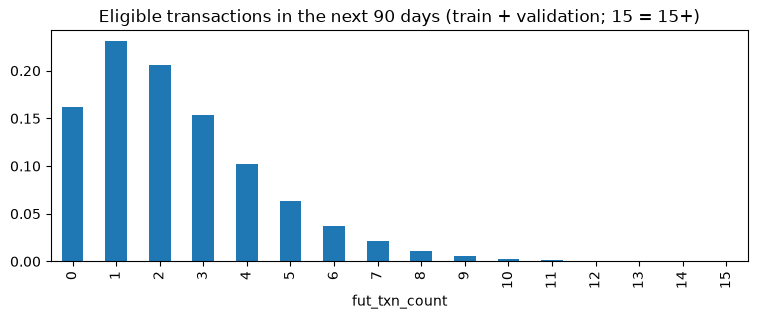

In [9]:
ax = rows.query("split != 'test'").fut_txn_count.clip(upper=15).value_counts(normalize=True).sort_index().plot.bar(
    figsize=(9, 3), title="Eligible transactions in the next 90 days (train + validation; 15 = 15+)")
rows.query("split != 'test'").fut_txn_count.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2)

## 6. Evidence that past behaviour predicts future activity

Risk rate by recency and frequency bucket, from training snapshots. If behaviour carried no signal, every
bucket would show the overall rate.

In [10]:
train, valid = rows.query("split == 'train'").copy(), rows.query("split == 'validation'").copy()
rec_bins = [-1, 7, 14, 30, 60, 90, 180, 365]
freq_bins = [-1, 0, 1, 2, 4, 8, 16, np.inf]
by_recency = train.groupby(pd.cut(train.days_since_last_txn, rec_bins), observed=True).agg(
    customers=("customer_id", "size"), risk_A=("risk_A", "mean"), risk_B=("risk_B", "mean"))
by_frequency = train.groupby(pd.cut(train.txn_count_90d, freq_bins), observed=True).agg(
    customers=("customer_id", "size"), risk_A=("risk_A", "mean"), risk_B=("risk_B", "mean"))
display(by_recency.round(3))
by_frequency.round(3)

,customers,risk_A,risk_B
days_since_last_txn,,,
"(-1, 7]",71117,0.101,0.279
"(7, 14]",58145,0.110,0.298
"(14, 30]",91037,0.127,0.333
"(30, 60]",93515,0.162,0.399
"(60, 90]",47160,0.208,0.479
"(90, 180]",49717,0.265,0.579
"(180, 365]",17979,0.356,0.709


,customers,risk_A,risk_B
txn_count_90d,,,
"(-1.0, 0.0]",67696,0.289,0.613
"(0.0, 1.0]",100531,0.228,0.516
"(1.0, 2.0]",88582,0.162,0.409
"(2.0, 4.0]",109789,0.094,0.278
"(4.0, 8.0]",57170,0.039,0.149
"(8.0, 16.0]",4894,0.012,0.050
"(16.0, inf]",8,0.000,0.000


In [11]:
# Customer-level persistence: future count correlates with past count far beyond what independent customers would give.
print("Spearman past-180d count vs next-90d count (train):",
      round(pd.Series(train.txn_count_180d).corr(train.fut_txn_count, method="spearman"), 3))
print("Spearman days-since-last vs next-90d count (train):",
      round(pd.Series(train.days_since_last_txn).corr(train.fut_txn_count, method="spearman"), 3))

Spearman past-180d count vs next-90d count (train): 0.473
Spearman days-since-last vs next-90d count (train): -0.267


## 7. Baselines and a linear probe

Scores are oriented so a higher score means more risk. Each rule's decision threshold is chosen on the
**training** snapshots (the F1-maximising point of `precision_recall_curve`) and applied unchanged to
validation. Metrics come from scikit-learn.

* **Majority class**: always predict the majority. ROC-AUC 0.5; PR-AUC equals the prevalence.
* **Recency rule**: score = `days_since_last_txn` (risk above the chosen number of days).
* **Frequency rule**: score = −`txn_count_90d`.
* **RF score**: the mean of recency and frequency percentile ranks. No fitting; a classic RFM-style combination.
* **Linear probe**: scikit-learn `LogisticRegression` on signed-`log1p`, standardised features, fitted on
  training snapshots only. This is **not** the final model; it estimates how much a learned model can add
  over the simple rules. It is fitted twice: with all features, and with transaction features only, to see
  whether campaigns, service, digital and relationship features add anything.

Business view: `recall@top10%` / `recall@top20%` is the share of all at-risk customers a retention campaign
reaches if it can contact only the 10 % or 20 % with the highest risk score; `lift@top10%` is that recall
divided by 0.10.

In [12]:
def recall_at_top(y, score, frac):
    """Share of all positives among the `frac` highest scores. scikit-learn has no equivalent for a binary
    capacity-limited recall (top_k_accuracy_score is per-sample multiclass), so it is computed here;
    ties keep the fixed row order."""
    y, order = np.asarray(y), np.argsort(-np.asarray(score), kind="stable")
    return y[order[: int(np.ceil(frac * len(order)))]].sum() / y.sum()


def f1_threshold(y, score):
    """Score threshold that maximises F1 for the positive class (chosen on training data only)."""
    precision, recall, thresholds = precision_recall_curve(y, score)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    return thresholds[np.argmax(f1[:-1])]


def evaluate(name, y_va, s_va, threshold):
    pred = np.asarray(s_va) >= threshold
    p, r, f1, _ = precision_recall_fscore_support(y_va, pred, average="binary", zero_division=0)
    return {"model": name, "prevalence": np.mean(y_va), "ROC-AUC": roc_auc_score(y_va, s_va),
            "PR-AUC": average_precision_score(y_va, s_va), "precision": p, "recall": r, "F1": f1,
            "recall@top10%": recall_at_top(y_va, s_va, 0.10), "recall@top20%": recall_at_top(y_va, s_va, 0.20),
            "lift@top10%": recall_at_top(y_va, s_va, 0.10) / 0.10, "threshold": threshold}


def rf_score(df):
    return ((df.days_since_last_txn.rank(pct=True) + (-df.txn_count_90d).rank(pct=True)) / 2).values


def signed_log1p(X):
    return np.sign(X) * np.log1p(np.abs(X))


def linear_probe():
    return make_pipeline(FunctionTransformer(signed_log1p), StandardScaler(), LogisticRegression(max_iter=2000))


NON_TXN = ["tenure_days", "products_opened", "sends_180d", "opens_180d", "clicks_180d", "days_since_last_click",
           "contacts_180d", "complaints_180d", "logins_90d", "digital_active_days_90d", "days_since_last_login"]
TXN_ONLY = [c for c in FEATURES if c not in NON_TXN]
RULES = {"recency rule (days since last txn)": lambda d: d.days_since_last_txn.values.astype(float),
         "frequency rule (-txn_count_90d)": lambda d: -d.txn_count_90d.values.astype(float),
         "RF score (recency + frequency ranks)": rf_score}

results, probes, scores = [], {}, {}
for target in ("risk_A", "risk_B"):
    ytr, yva = train[target].values, valid[target].values
    majority = int(ytr.mean() >= 0.5)
    p, r, f1, _ = precision_recall_fscore_support(yva, np.full(len(yva), majority), average="binary", zero_division=0)
    constant = np.zeros(len(yva))
    results.append({"target": target, "model": f"majority (always {'risk' if majority else 'active'})", "prevalence": yva.mean(),
                    "ROC-AUC": roc_auc_score(yva, constant), "PR-AUC": average_precision_score(yva, constant),
                    "precision": p, "recall": r, "F1": f1, "recall@top10%": recall_at_top(yva, constant, 0.10),
                    "recall@top20%": recall_at_top(yva, constant, 0.20), "lift@top10%": recall_at_top(yva, constant, 0.10) / 0.10})
    for name, rule in RULES.items():
        s_tr, s_va = rule(train), rule(valid)
        results.append({"target": target, **evaluate(name, yva, s_va, f1_threshold(ytr, s_tr))})
        scores[(target, name)] = s_va
    for name, cols in (("linear probe (all features)", FEATURES), ("linear probe (transaction features only)", TXN_ONLY)):
        model = linear_probe().fit(train[cols], ytr)
        s_tr, s_va = model.predict_proba(train[cols])[:, 1], model.predict_proba(valid[cols])[:, 1]
        results.append({"target": target, **evaluate(name, yva, s_va, f1_threshold(ytr, s_tr))})
        probes[(target, name)], scores[(target, name)] = model, s_va
metrics = pd.DataFrame(results).set_index(["target", "model"])
metrics.drop(columns="threshold").round(4)

prevalence  ROC-AUC  PR-AUC  precision  recall      F1  recall@top10%  recall@top20%  lift@top10%
target model                                                                                                                                      
risk_A majority (always active)                      0.1620   0.5000  0.1620     0.0000  0.0000  0.0000         0.1012         0.2006       1.0118
       recency rule (days since last txn)            0.1620   0.6234  0.2474     0.2314  0.5274  0.3217         0.1911         0.3361       1.9109
       frequency rule (-txn_count_90d)               0.1620   0.6751  0.2437     0.2530  0.6094  0.3575         0.1773         0.3389       1.7727
       RF score (recency + frequency ranks)          0.1620   0.6634  0.2605     0.2388  0.6114  0.3434         0.1911         0.3394       1.9109
       linear probe (all features)                   0.1620   0.7487  0.3202     0.3154  0.6236  0.4189         0.2305         0.4298       2.3051
       linear probe (transaction features only)      0.1620   0.7178  0.2869     0.2810  0.6331  0.3892         0.2054         0.3909       2.0537
risk_B majority (always active)                      0.3911   0.5000  0.3911     0.0000  0.0000  0.0000         0.1008         0.2001       1.0079
       recency rule (days since last txn)            0.3911   0.6291  0.5295     0.4104  0.8972  0.5632         0.1656         0.2995       1.6564
       frequency rule (-txn_count_90d)               0.3911   0.6849  0.5299     0.4608  0.8865  0.6064         0.1560         0.3012       1.5599
       RF score (recency + frequency ranks)          0.3911   0.6726  0.5524     0.4546  0.8618  0.5952         0.1656         0.3014       1.6564
       linear probe (all features)                   0.3911   0.7623  0.6404     0.5592  0.7807  0.6516         0.1872         0.3573       1.8716
       linear probe (transaction features only)      0.3911   0.7290  0.5935     0.5228  0.8001  0.6324         0.1718         0.3327       1.7182

In [13]:
# The recency rule's chosen threshold, in days, and what it flags.
for target in ("risk_A", "risk_B"):
    t = f1_threshold(train[target].values, train.days_since_last_txn.values.astype(float))
    print(f"{target}: flag customers with no eligible transaction for >= {t:.0f} days "
          f"({(valid.days_since_last_txn >= t).mean():.1%} of validation customers flagged)")

risk_A: flag customers with no eligible transaction for >= 44 days (36.9% of validation customers flagged)
risk_B: flag customers with no eligible transaction for >= 7 days (85.5% of validation customers flagged)


In [14]:
# Confusion matrices at the training-chosen thresholds (validation), risk class = 1.
for target, name in (("risk_B", "RF score (recency + frequency ranks)"), ("risk_B", "linear probe (all features)"),
                     ("risk_A", "linear probe (all features)")):
    t = metrics.loc[(target, name), "threshold"]
    cm = confusion_matrix(valid[target], scores[(target, name)] >= t, labels=[0, 1])
    print(f"{target} | {name}\n", pd.DataFrame(cm, index=["actual active", "actual risk"], columns=["pred active", "pred risk"]), "\n")

risk_B | RF score (recency + frequency ranks)
                pred active  pred risk
actual active        48955      96862
actual risk          12943      80726 

risk_B | linear probe (all features)
                pred active  pred risk
actual active        88173      57644
actual risk          20542      73127 

risk_A | linear probe (all features)
                pred active  pred risk
actual active       148180      52513
actual risk          14602      24191 



In [15]:
# Standardised coefficients of the all-feature probe (risk_B): which signals carry the prediction.
lr = probes[("risk_B", "linear probe (all features)")][-1]
coef = pd.Series(lr.coef_[0], index=FEATURES)
pd.DataFrame({"coef": coef, "abs": coef.abs()}).sort_values("abs", ascending=False).head(15).round(3)

,coef,abs
txn_count_180d,-0.586,0.586
products_opened,-0.563,0.563
txn_count_90d,-0.346,0.346
active_days_90d,0.243,0.243
active_days_180d,0.241,0.241
n_txn_types_180d,-0.206,0.206
txn_count_30d,-0.206,0.206
txns_per_active_day_180d,0.123,0.123
count_trend_30d_vs_prior60d,0.119,0.119
count_ratio_90d_vs_prior90d,0.103,0.103


In [16]:
# Stability: the same metrics per validation snapshot (risk_B), RF score vs probe.
model = probes[("risk_B", "linear probe (all features)")]
per_snap = []
for T, part in valid.groupby("snapshot_date"):
    for name, s in (("RF score", rf_score(part)), ("linear probe", model.predict_proba(part[FEATURES])[:, 1])):
        per_snap.append({"snapshot_date": T.date(), "model": name, "prevalence": part.risk_B.mean(),
                         "ROC-AUC": roc_auc_score(part.risk_B, s), "PR-AUC": average_precision_score(part.risk_B, s),
                         "recall@top20%": recall_at_top(part.risk_B, s, 0.2)})
pd.DataFrame(per_snap).round(4)

,snapshot_date,model,prevalence,ROC-AUC,PR-AUC,recall@top20%
0,2025-07-01,RF score,0.3906,0.6737,0.5535,0.3026
1,2025-07-01,linear probe,0.3906,0.7623,0.6395,0.3576
2,2025-10-01,RF score,0.3916,0.6715,0.5515,0.3003
3,2025-10-01,linear probe,0.3916,0.7625,0.6415,0.3573


## 8. Alternative: campaign click / engagement

Target: a delivered send is clicked. For each quarterly snapshot T, the features use only sends, opens and
clicks dated before T: the customer's past delivered sends, open rate and click rate, plus the channel of the
send. The rows are the sends in [T, T + 90d).

The probe trains on training quarters (2025-01-01, 2025-04-01) and is evaluated on validation quarters
(2025-07-01, 2025-10-01). If clicks were customer-specific, a customer's past click rate would separate
clickers from non-clickers *within* a channel.

In [17]:
def click_rows(snapshots):
    snaps = ", ".join(f"TIMESTAMP '{T}'" for T in snapshots)
    return q(f"""
    WITH s AS (SELECT unnest([{snaps}]) AS T),
    hist AS (SELECT e.customer_id, s.T, count(*) FILTER (WHERE e.was_delivered) AS past_delivered,
                    count(*) FILTER (WHERE e.open_date < s.T) AS past_opens, count(*) FILTER (WHERE e.click_date < s.T) AS past_clicks
             FROM eng_sends e JOIN s ON e.send_date < s.T GROUP BY e.customer_id, s.T)
    SELECT e.customer_id, s.T AS snapshot_date, e.send_channel, e.was_clicked::INT AS clicked, e.was_opened::INT AS opened,
           coalesce(h.past_delivered, 0) AS past_delivered,
           coalesce(h.past_clicks / nullif(h.past_delivered, 0), 0) AS past_click_rate,
           coalesce(h.past_opens / nullif(h.past_delivered, 0), 0) AS past_open_rate
    FROM eng_sends e JOIN s ON e.send_date >= s.T AND e.send_date < s.T + INTERVAL 90 DAY
    LEFT JOIN hist h ON h.customer_id = e.customer_id AND h.T = s.T
    WHERE e.was_delivered
    ORDER BY snapshot_date, customer_id""")


click_train, click_valid = click_rows(["2025-01-01", "2025-04-01"]), click_rows(["2025-07-01", "2025-10-01"])
click_valid.groupby("send_channel").agg(sends=("clicked", "size"), click_rate=("clicked", "mean"), open_rate=("opened", "mean")).round(4)

,sends,click_rate,open_rate
send_channel,,,
Email,92376,0.0599,0.2986
Push,54602,0.0790,0.3993
SMS,56117,0.0988,0.4975
Voice,981,0.0000,0.0000
WhatsApp,68699,0.0000,0.0000


In [18]:
NUM = ["past_delivered", "past_click_rate", "past_open_rate"]
channel_rate = click_train.groupby("send_channel").clicked.mean()
y_tr, y_va = click_train.clicked.values, click_valid.clicked.values


def click_probe(cols, channel):
    """Logistic regression on the numeric history (standardised) and, optionally, the one-hot channel."""
    parts = [("num", StandardScaler(), cols)] + ([("chan", OneHotEncoder(handle_unknown="ignore"), ["send_channel"])] if channel else [])
    return make_pipeline(ColumnTransformer(parts), LogisticRegression(max_iter=2000))


click_scores = {
    "channel only (train click rate)": click_valid.send_channel.map(channel_rate).fillna(0).values,
    "customer past click rate": click_valid.past_click_rate.values,
    "customer past open rate": click_valid.past_open_rate.values,
    "probe: history only": click_probe(NUM, False).fit(click_train, y_tr).predict_proba(click_valid)[:, 1],
    "probe: history + channel": click_probe(NUM, True).fit(click_train, y_tr).predict_proba(click_valid)[:, 1],
}
click_table = pd.DataFrame([{"score": k, "ROC-AUC": roc_auc_score(y_va, s), "PR-AUC": average_precision_score(y_va, s),
                             "recall@top10%": recall_at_top(y_va, s, 0.10)} for k, s in click_scores.items()])
# Within each channel that records clicks, does the customer's history separate clickers at all?
tracked = [c for c, g in click_valid.groupby("send_channel") if g.clicked.nunique() == 2]
within = {c: roc_auc_score(g.clicked, g.past_click_rate) for c, g in click_valid.groupby("send_channel") if c in tracked}
print(f"click prevalence (validation): {y_va.mean():.4f} over {len(y_va):,} delivered sends")
print("within-channel ROC-AUC of past click rate:", {c: round(v, 4) for c, v in within.items()})
click_table.round(4)

click prevalence (validation): 0.0564 over 272,775 delivered sends
within-channel ROC-AUC of past click rate: {'Email': 0.5063, 'Push': 0.4989, 'SMS': 0.5029}


,score,ROC-AUC,PR-AUC,recall@top10%
0,channel only (train click rate),0.6807,0.0878,0.1753
1,customer past click rate,0.5029,0.0569,0.1046
2,customer past open rate,0.5034,0.0570,0.1028
3,probe: history only,0.5027,0.0569,0.0996
4,probe: history + channel,0.6813,0.0912,0.1758


## 9. Feasibility findings (before LightGBM)

**Recommended target.** `low_engagement_next_90d = 1` when the customer has **fewer than 2** eligible
transactions in [T, T + 90d). Eligible means approved Purchase, Payment, Transfer, Withdrawal or Deposit.
The population at T is customers registered before T with at least one eligible transaction in
[T − 365d, T).

* It is balanced: 39 % positive, stable from 39.0 % to 40.0 % across all seven snapshots.
* It flags customers who are lapsing *before* they go fully silent, which is when a retention benefit still
  has something to retain.
* It is the most separable of the candidates: PR-AUC 0.640 for the probe.

Full inactivity (`fut = 0`, 16 % positive) is a stricter variant with the same signal (probe ROC-AUC 0.749),
useful as a "win-back" tier. The three-level split, inactive / low / high = 16 / 44 / 40 %, maps naturally
onto strategy tiers, but was not modelled here.

**Distribution.** Over train and validation, eligible transactions in the next 90 days have mean 2.41 and
median 2; 10 % have 0, 25 % at most 1, 75 % at most 3, 90 % at most 5.

**Past behaviour predicts future activity**, unlike categories:

* Lifetime counts are overdispersed: variance 9.7× the mean, so customers have their own activity rate.
* The low-engagement rate rises steadily with recency: 28 % for customers active within the last 7 days,
  71 % for those last active 180–365 days ago.
* It falls steadily with 90-day frequency: 61 % with no transactions, 5 % with 9–16.
* Spearman correlation between the past 180-day count and the next 90-day count: 0.47.

**Baselines (validation, 239,486 customer × snapshot rows; thresholds chosen on training snapshots).**

| Target | Model | ROC-AUC | PR-AUC | Precision | Recall | F1 | Recall@top10% | Recall@top20% |
|---|---|---|---|---|---|---|---|---|
| < 2 txns (39.1 %) | majority (always active) | 0.500 | 0.391 | 0 | 0 | 0 | 0.10 | 0.20 |
| | recency rule | 0.629 | 0.530 | 0.410 | 0.897 | 0.563 | 0.166 | 0.300 |
| | frequency rule (−count 90d) | **0.685** | 0.530 | 0.461 | 0.887 | 0.606 | 0.156 | 0.301 |
| | RF score (recency + frequency ranks) | 0.673 | **0.552** | 0.455 | 0.862 | 0.595 | 0.166 | 0.301 |
| | linear probe, transaction features | 0.729 | 0.594 | 0.523 | 0.800 | 0.632 | 0.172 | 0.333 |
| | **linear probe, all features** | **0.762** | **0.640** | 0.559 | 0.781 | 0.652 | 0.187 | 0.357 |
| 0 txns (16.2 %) | RF score | 0.663 | 0.261 | 0.239 | 0.611 | 0.343 | 0.191 | 0.339 |
| | linear probe, all features | 0.749 | 0.320 | 0.315 | 0.624 | 0.419 | 0.231 | 0.430 |

The F1-optimal thresholds of the single rules are very permissive. For the < 2 target, the recency rule
flags anyone silent for ≥ 7 days, which is 85.5 % of customers. For retention, the capacity view
(recall@top-k) is the useful one.

**Room for a learned model.** Yes, and it is measurable:

* A plain logistic regression already improves on the best rule by about 0.08 ROC-AUC and 0.09 PR-AUC,
  and captures 36 % of low-engagement customers in the top 20 % (vs 30 % for RF).
* The gain is identical on both validation snapshots (0.762 / 0.763).
* Non-transaction sources add about 0.03 AUC. The largest is `products_opened`, the number of products
  opened before T.

LightGBM can add interactions and non-linear recency/frequency shapes on top. Two caveats:

* Several count features are collinear, so the probe's coefficient signs should not be read individually.
* `products_opened` counts products by opening date only, because no point-in-time product status exists.

**Campaign click / engagement is the weaker problem.**

* Channel alone gives ROC-AUC 0.681. WhatsApp and Voice record no clicks at all.
* Within each tracked channel, the customer's past click and open rates have ROC-AUC 0.499–0.506, i.e.
  none. The history + channel probe (0.681) equals channel alone.

So clicks depend on the channel the campaign chose, not on who the customer is. There is nothing
customer-specific to learn.

**Conclusion.** Inactivity / low-engagement risk is the stronger ML problem for this loyalty system.
Customer behaviour clearly predicts it, simple rules leave measurable headroom, and the score maps directly
onto a retention strategy. It is the target to take into the first LightGBM experiment.

## 10. Model comparison protocol (LightGBM vs baselines)

Target: `low_engagement_next_90d` = `risk_B` (fewer than 2 eligible transactions in [T, T + 90d)). The
population, features, snapshots and splits are those defined above.

* Every model is fit on the **train** snapshots only.
* The **validation** snapshots are the selection set:
  * LightGBM hyperparameters and early stopping are chosen on validation PR-AUC.
  * Every model's decision threshold is the F1-maximising point on validation; that includes the rules and
    the logistic regressions. Section 7 chose rule thresholds on train, so its precision / recall / F1 differ.
* Threshold-based validation metrics are therefore slightly optimistic for every model alike. ROC-AUC, PR-AUC
  and the top-k metrics do not use a threshold.
* The **test** snapshot (2026-01-01) is used once, in section 14, with every model and threshold frozen.

Business metrics: `recall@top20%` is the share of all low-engagement customers among the 20 % with the
highest score; `precision@top20%` is the share of that 20 % who really are low-engagement; `lift@top20%` is
that precision divided by the base rate.

In [19]:
import lightgbm as lgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import ParameterSampler

SEED = 7
TARGET = "risk_B"
test = rows.query("split == 'test'").copy()  # not touched until section 14
y_tr, y_va = train[TARGET].values, valid[TARGET].values


def top_mask(score, frac):
    order = np.argsort(-np.asarray(score, dtype=float), kind="stable")
    mask = np.zeros(len(order), dtype=bool)
    mask[order[: int(np.ceil(frac * len(order)))]] = True
    return mask


def full_metrics(y, score, threshold):
    """The same metrics for every model. Top-k uses the fixed row order for ties."""
    y, score = np.asarray(y), np.asarray(score, dtype=float)
    p, r, f1, _ = precision_recall_fscore_support(y, score >= threshold, average="binary", zero_division=0)
    t10, t20 = top_mask(score, 0.10), top_mask(score, 0.20)
    prevalence = y.mean()
    return {"prevalence": prevalence, "ROC-AUC": roc_auc_score(y, score), "PR-AUC": average_precision_score(y, score),
            "precision": p, "recall": r, "F1": f1,
            "recall@top10%": y[t10].sum() / y.sum(), "recall@top20%": y[t20].sum() / y.sum(),
            "precision@top20%": y[t20].mean(), "lift@top20%": y[t20].mean() / prevalence}


lr_txn = linear_probe().fit(train[TXN_ONLY], y_tr)
lr_all = linear_probe().fit(train[FEATURES], y_tr)
SCORERS = {
    "1 majority (always active)": lambda d: np.zeros(len(d)),
    "2 recency rule": lambda d: d.days_since_last_txn.values.astype(float),
    "3 frequency rule": lambda d: -d.txn_count_90d.values.astype(float),
    "4 recency + frequency ranks": rf_score,
    "5 logistic regression (transaction features)": lambda d: lr_txn.predict_proba(d[TXN_ONLY])[:, 1],
    "6 logistic regression (all features)": lambda d: lr_all.predict_proba(d[FEATURES])[:, 1],
}

## 11. LightGBM: small seeded search on validation

`LGBMClassifier` on the same 26 features as the all-feature logistic regression. Twelve configurations are
drawn with a fixed seed, each with early stopping on validation average precision. The best configuration
is then refit on train with its best number of trees, so the final model is reproducible. Every fit uses
`deterministic=True`, a fixed thread count and fixed seeds.

In [20]:
BASE = dict(objective="binary", metric="average_precision", n_estimators=3000, subsample_freq=1, random_state=SEED,
            deterministic=True, force_col_wise=True, n_jobs=8, verbose=-1)
SPACE = {"learning_rate": [0.03, 0.05, 0.1], "num_leaves": [15, 31, 63, 127], "max_depth": [-1, 6, 10],
         "min_child_samples": [50, 200, 500], "subsample": [0.7, 0.85, 1.0], "colsample_bytree": [0.6, 0.8, 1.0],
         "reg_alpha": [0.0, 0.1, 1.0], "reg_lambda": [0.0, 1.0, 5.0]}
trials, started = [], time.time()
for i, params in enumerate(ParameterSampler(SPACE, n_iter=12, random_state=SEED)):
    model = lgb.LGBMClassifier(**BASE, **params).fit(
        train[FEATURES], y_tr, eval_X=(valid[FEATURES],), eval_y=(y_va,), callbacks=[lgb.early_stopping(100, verbose=False)])
    s = model.predict_proba(valid[FEATURES], num_iteration=model.best_iteration_)[:, 1]
    trials.append({"trial": i, **params, "trees": model.best_iteration_, "val PR-AUC": average_precision_score(y_va, s),
                   "val ROC-AUC": roc_auc_score(y_va, s), "val recall@top20%": y_va[top_mask(s, 0.2)].sum() / y_va.sum()})
trials = pd.DataFrame(trials).sort_values("val PR-AUC", ascending=False)
print(f"search: {len(trials)} configurations in {time.time() - started:.0f}s")
trials.round(4)

search: 12 configurations in 81s


,trial,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_depth,learning_rate,colsample_bytree,trees,val PR-AUC,val ROC-AUC,val recall@top20%
2,2,1.00,1.0,0.1,127,50,6,0.05,0.8,77,0.6478,0.7657,0.3637
5,5,0.70,5.0,0.0,15,200,10,0.05,1.0,168,0.6477,0.7658,0.3636
4,4,0.85,1.0,1.0,63,50,6,0.05,0.6,169,0.6476,0.7655,0.3638
9,9,0.85,5.0,0.1,63,500,-1,0.03,1.0,188,0.6475,0.7656,0.3636
7,7,0.85,1.0,0.1,15,500,6,0.05,0.8,233,0.6475,0.7657,0.3635
11,11,0.85,5.0,1.0,31,200,6,0.05,0.6,170,0.6474,0.7657,0.3636
0,0,0.70,5.0,1.0,127,200,6,0.03,0.6,316,0.6473,0.7656,0.3635
10,10,0.70,1.0,0.1,15,200,-1,0.05,0.6,267,0.6473,0.7657,0.3635
3,3,0.85,0.0,0.0,63,500,10,0.03,0.6,195,0.6473,0.7655,0.3636
8,8,1.00,5.0,1.0,127,500,-1,0.03,0.8,114,0.6472,0.7654,0.3637


In [21]:
best = trials.iloc[0]
BEST_PARAMS = {k: (best[k].item() if hasattr(best[k], "item") else best[k]) for k in SPACE}
BEST_PARAMS = {k: int(v) if k in ("num_leaves", "max_depth", "min_child_samples") else float(v) for k, v in BEST_PARAMS.items()}
BEST_TREES = int(best.trees)
final_params = {**BASE, **BEST_PARAMS, "n_estimators": BEST_TREES}
lgbm = lgb.LGBMClassifier(**final_params).fit(train[FEATURES], y_tr)
again = lgb.LGBMClassifier(**final_params).fit(train[FEATURES], y_tr)
assert np.allclose(lgbm.predict_proba(valid[FEATURES])[:, 1], again.predict_proba(valid[FEATURES])[:, 1])  # reproducible
SCORERS["7 LightGBM"] = lambda d: lgbm.predict_proba(d[FEATURES])[:, 1]
print("best parameters:", BEST_PARAMS, "| trees:", BEST_TREES)

best parameters: {'learning_rate': 0.05, 'num_leaves': 127, 'max_depth': 6, 'min_child_samples': 50, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0} | trees: 77


## 12. Validation comparison (all seven models, same metrics)

In [22]:
THRESHOLDS, val_rows = {}, []
for name, scorer in SCORERS.items():
    s = scorer(valid)
    THRESHOLDS[name] = np.inf if name.startswith("1 ") else f1_threshold(y_va, s)  # majority flags nobody
    val_rows.append({"model": name, **full_metrics(y_va, s, THRESHOLDS[name])})
val_table = pd.DataFrame(val_rows).set_index("model")
val_table.round(4)

,prevalence,ROC-AUC,PR-AUC,precision,recall,F1,recall@top10%,recall@top20%,precision@top20%,lift@top20%
model,,,,,,,,,,
1 majority (always active),0.3911,0.5000,0.3911,0.0000,0.0000,0.0000,0.1008,0.2001,0.3913,1.0004
2 recency rule,0.3911,0.6291,0.5295,0.4067,0.9161,0.5634,0.1656,0.2995,0.5858,1.4976
3 frequency rule,0.3911,0.6849,0.5299,0.5014,0.7674,0.6065,0.1560,0.3012,0.5890,1.5060
4 recency + frequency ranks,0.3911,0.6726,0.5524,0.4585,0.8504,0.5957,0.1656,0.3014,0.5894,1.5069
5 logistic regression (transaction features),0.3911,0.7290,0.5935,0.5239,0.7981,0.6325,0.1718,0.3327,0.6507,1.6635
6 logistic regression (all features),0.3911,0.7623,0.6404,0.5545,0.7920,0.6523,0.1872,0.3573,0.6987,1.7864
7 LightGBM,0.3911,0.7657,0.6478,0.5595,0.7876,0.6543,0.1885,0.3637,0.7112,1.8183


In [23]:
# Per validation snapshot: is the ordering of models stable?
per = []
for T, part in valid.groupby("snapshot_date"):
    for name in ("3 frequency rule", "4 recency + frequency ranks", "6 logistic regression (all features)", "7 LightGBM"):
        s = SCORERS[name](part)
        m = full_metrics(part[TARGET].values, s, THRESHOLDS[name])
        per.append({"snapshot_date": T.date(), "model": name, **{k: m[k] for k in ("ROC-AUC", "PR-AUC", "recall@top20%", "lift@top20%")}})
pd.DataFrame(per).round(4)

,snapshot_date,model,ROC-AUC,PR-AUC,recall@top20%,lift@top20%
0,2025-07-01,3 frequency rule,0.6864,0.5310,0.3034,1.5168
1,2025-07-01,4 recency + frequency ranks,0.6737,0.5535,0.3026,1.5128
2,2025-07-01,6 logistic regression (all features),0.7623,0.6395,0.3576,1.7879
3,2025-07-01,7 LightGBM,0.7653,0.6461,0.3633,1.8166
4,2025-10-01,3 frequency rule,0.6834,0.5289,0.3009,1.5045
5,2025-10-01,4 recency + frequency ranks,0.6715,0.5515,0.3003,1.5012
6,2025-10-01,6 logistic regression (all features),0.7625,0.6415,0.3573,1.7867
7,2025-10-01,7 LightGBM,0.7663,0.6496,0.3637,1.8185


## 13. Interpretation (associations, not causes)

* **Gain importance**: the share of total split gain per feature in the final model.
* **Permutation importance**: the drop in validation PR-AUC when one feature is shuffled. This uses a
  60k-row validation sample and 3 repeats; it is closer to "what the model relies on".
* **Additive check**: the same LightGBM setup with single-split trees (no interactions). If it matches the
  full model, the gain over logistic regression comes from non-linear shapes rather than interactions.
* **Leakage scan**: each feature's own validation ROC-AUC. A single feature scoring near 1 would be
  suspicious.

In [24]:
GROUPS = {
    "recency / frequency": ["txn_count_30d", "txn_count_90d", "txn_count_180d", "active_days_90d", "active_days_180d",
                            "days_since_last_txn", "txns_per_active_day_180d", "count_trend_30d_vs_prior60d",
                            "count_ratio_90d_vs_prior90d"],
    "spend / breadth": ["spend_usd_30d", "spend_usd_90d", "spend_usd_180d", "n_txn_types_180d", "n_categories_180d", "declined_count_90d"],
    "relationship": ["tenure_days", "products_opened"],
    "campaigns": ["sends_180d", "opens_180d", "clicks_180d", "days_since_last_click"],
    "service": ["contacts_180d", "complaints_180d"],
    "digital": ["logins_90d", "digital_active_days_90d", "days_since_last_login"],
}
assert sorted(sum(GROUPS.values(), [])) == sorted(FEATURES)
group_of = {f: g for g, fs in GROUPS.items() for f in fs}

gain = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"), index=FEATURES)
sample = valid.sample(60_000, random_state=SEED)
perm = permutation_importance(lgbm, sample[FEATURES], sample[TARGET].values, scoring="average_precision",
                              n_repeats=3, random_state=SEED, n_jobs=1)
importance = pd.DataFrame({"group": pd.Series(group_of), "gain_share": gain / gain.sum(),
                           "perm_PR-AUC_drop": pd.Series(perm.importances_mean, index=FEATURES),
                           "perm_std": pd.Series(perm.importances_std, index=FEATURES)}).sort_values("perm_PR-AUC_drop", ascending=False)
importance.head(15).round(4)

,group,gain_share,perm_PR-AUC_drop,perm_std
products_opened,relationship,0.6004,0.1091,0.0013
txn_count_180d,recency / frequency,0.2924,0.0309,0.0006
n_txn_types_180d,spend / breadth,0.0244,0.0087,0.0003
spend_usd_180d,spend / breadth,0.0069,0.0038,0.0011
declined_count_90d,spend / breadth,0.0043,0.0018,0.0003
days_since_last_txn,recency / frequency,0.0055,0.0015,0.0002
active_days_180d,recency / frequency,0.0433,0.0012,0.0003
tenure_days,relationship,0.0017,0.0008,0.0004
n_categories_180d,spend / breadth,0.0049,0.0006,0.0001
txn_count_90d,recency / frequency,0.0062,0.0004,0.0003


In [25]:
importance.groupby("group")[["gain_share", "perm_PR-AUC_drop"]].sum().sort_values("gain_share", ascending=False).round(4)

,gain_share,perm_PR-AUC_drop
group,,
relationship,0.6021,0.1099
recency / frequency,0.3511,0.0340
spend / breadth,0.0432,0.0150
digital,0.0019,0.0002
campaigns,0.0013,0.0001
service,0.0004,0.0001


In [26]:
stumps = lgb.LGBMClassifier(**{**BASE, **BEST_PARAMS, "num_leaves": 2, "max_depth": 1}).fit(
    train[FEATURES], y_tr, eval_X=(valid[FEATURES],), eval_y=(y_va,), callbacks=[lgb.early_stopping(100, verbose=False)])
s_stump = stumps.predict_proba(valid[FEATURES], num_iteration=stumps.best_iteration_)[:, 1]
pd.DataFrame([
    {"model": "logistic regression (all features)", "val PR-AUC": val_table.loc["6 logistic regression (all features)", "PR-AUC"],
     "val ROC-AUC": val_table.loc["6 logistic regression (all features)", "ROC-AUC"]},
    {"model": f"LightGBM additive (single-split trees, {stumps.best_iteration_} trees)", "val PR-AUC": average_precision_score(y_va, s_stump),
     "val ROC-AUC": roc_auc_score(y_va, s_stump)},
    {"model": "LightGBM (selected, with interactions)", "val PR-AUC": val_table.loc["7 LightGBM", "PR-AUC"],
     "val ROC-AUC": val_table.loc["7 LightGBM", "ROC-AUC"]},
]).round(4)

,model,val PR-AUC,val ROC-AUC
0,logistic regression (all features),0.6404,0.7623
1,"LightGBM additive (single-split trees, 466 trees)",0.6450,0.7651
2,"LightGBM (selected, with interactions)",0.6478,0.7657


In [27]:
single = pd.Series({f: roc_auc_score(y_va, valid[f].astype(float)) for f in FEATURES})
leak_scan = pd.DataFrame({"single_feature_ROC-AUC": single, "oriented": np.maximum(single, 1 - single)}).sort_values("oriented", ascending=False)
print("max single-feature AUC:", round(leak_scan.oriented.max(), 4), "->", leak_scan.oriented.idxmax())
leak_scan.head(10).round(4)

max single-feature AUC: 0.7401 -> products_opened


,single_feature_ROC-AUC,oriented
products_opened,0.2599,0.7401
txn_count_180d,0.2748,0.7252
active_days_180d,0.2754,0.7246
n_txn_types_180d,0.2966,0.7034
txn_count_90d,0.3151,0.6849
active_days_90d,0.3158,0.6842
n_categories_180d,0.3641,0.6359
days_since_last_txn,0.6291,0.6291
spend_usd_180d,0.3722,0.6278
txn_count_30d,0.3881,0.6119


### Sensitivity: the dominant feature `products_opened`

`products_opened` (products whose opening date is before T) is the strongest feature: it has the largest
gain and permutation drop, and the highest single-feature AUC. It is point-in-time safe by date. But silver
flags many transactions as `before_product_opening`, i.e. opening dates are not consistent with transaction
history, and the feature may stand in for the customer's whole product holding. This check runs on
validation only and asks how much the models depend on it.

In [28]:
total = q("SELECT customer_id, count(*) AS products_total FROM eng_products GROUP BY 1")
v = valid.merge(total, on="customer_id", how="left").fillna({"products_total": 0})
before_opening = con.sql("SELECT count(*) FROM txn_raw WHERE list_contains(dq_reasons, 'before_product_opening')").fetchone()[0]
print(f"transactions flagged before_product_opening: {before_opening:,} of {len(rows) and con.sql('SELECT count(*) FROM txn_raw').fetchone()[0]:,}")
print(f"share of validation customers' products opened on/after T (not counted): {1 - v.products_opened.sum() / v.products_total.sum():.3f}")
print(f"Spearman products_opened vs all products in the table: {v.products_opened.corr(v.products_total, method='spearman'):.3f}")

no_prod = [f for f in FEATURES if f != "products_opened"]
lgbm_np = lgb.LGBMClassifier(**final_params).fit(train[no_prod], y_tr)
lr_np = linear_probe().fit(train[no_prod], y_tr)
sens = {"LightGBM (all features)": lgbm.predict_proba(valid[FEATURES])[:, 1],
        "LightGBM without products_opened": lgbm_np.predict_proba(valid[no_prod])[:, 1],
        "logistic regression (all features)": lr_all.predict_proba(valid[FEATURES])[:, 1],
        "logistic regression without products_opened": lr_np.predict_proba(valid[no_prod])[:, 1],
        "recency + frequency ranks": rf_score(valid)}
pd.DataFrame([{"model": k, "val ROC-AUC": roc_auc_score(y_va, s_), "val PR-AUC": average_precision_score(y_va, s_),
               "val recall@top20%": y_va[top_mask(s_, 0.2)].sum() / y_va.sum()} for k, s_ in sens.items()]).round(4)

transactions flagged before_product_opening: 827,610 of 4,425,008
share of validation customers' products opened on/after T (not counted): 0.104
Spearman products_opened vs all products in the table: 0.925


,model,val ROC-AUC,val PR-AUC,val recall@top20%
0,LightGBM (all features),0.7657,0.6478,0.3637
1,LightGBM without products_opened,0.7320,0.6035,0.3345
2,logistic regression (all features),0.7623,0.6404,0.3573
3,logistic regression without products_opened,0.7290,0.5939,0.3326
4,recency + frequency ranks,0.6726,0.5524,0.3014


## 14. Final evaluation on the untouched test snapshot (2026-01-01)

Everything here is frozen from sections 10–12: models fitted on train, LightGBM parameters and tree count
from the validation search, and thresholds from validation. The paired bootstrap (500 resamples of test
customers) gives 95 % intervals for LightGBM's difference to the strongest rule and to logistic regression.

In [29]:
y_te = test[TARGET].values
test_scores = {name: scorer(test) for name, scorer in SCORERS.items()}
test_table = pd.DataFrame([{"model": name, **full_metrics(y_te, s, THRESHOLDS[name])} for name, s in test_scores.items()]).set_index("model")
print(f"test: {len(test):,} customers at 2026-01-01, prevalence {y_te.mean():.4f}")
test_table.round(4)

test: 126,053 customers at 2026-01-01, prevalence 0.3939


,prevalence,ROC-AUC,PR-AUC,precision,recall,F1,recall@top10%,recall@top20%,precision@top20%,lift@top20%
model,,,,,,,,,,
1 majority (always active),0.3939,0.5000,0.3939,0.0000,0.0000,0.0000,0.0994,0.2002,0.3942,1.0009
2 recency rule,0.3939,0.6290,0.5326,0.4099,0.9198,0.5671,0.1661,0.2977,0.5862,1.4883
3 frequency rule,0.3939,0.6835,0.5314,0.5043,0.7612,0.6067,0.1535,0.2993,0.5894,1.4964
4 recency + frequency ranks,0.3939,0.6720,0.5554,0.4627,0.8494,0.5991,0.1661,0.2994,0.5897,1.4972
5 logistic regression (transaction features),0.3939,0.7282,0.5974,0.5255,0.7931,0.6321,0.1713,0.3330,0.6558,1.6650
6 logistic regression (all features),0.3939,0.7646,0.6504,0.5660,0.7755,0.6544,0.1904,0.3631,0.7151,1.8156
7 LightGBM,0.3939,0.7685,0.6563,0.5728,0.7694,0.6567,0.1910,0.3669,0.7225,1.8345


In [30]:
strongest_rule = val_table.loc[[n for n in SCORERS if n[0] in "234"], "PR-AUC"].idxmax()
rng = np.random.default_rng(SEED)
boot = []
for _ in range(500):
    i = rng.integers(0, len(y_te), len(y_te))
    row = {}
    for other in (strongest_rule, "6 logistic regression (all features)"):
        a, b = test_scores["7 LightGBM"][i], test_scores[other][i]
        row[f"PR-AUC vs {other}"] = average_precision_score(y_te[i], a) - average_precision_score(y_te[i], b)
        row[f"ROC-AUC vs {other}"] = roc_auc_score(y_te[i], a) - roc_auc_score(y_te[i], b)
        row[f"recall@top20% vs {other}"] = y_te[i][top_mask(a, 0.2)].sum() / y_te[i].sum() - y_te[i][top_mask(b, 0.2)].sum() / y_te[i].sum()
    boot.append(row)
boot = pd.DataFrame(boot)
print("strongest deterministic baseline on validation (PR-AUC):", strongest_rule)
pd.DataFrame({"LightGBM minus": boot.columns, "mean": boot.mean().values,
              "ci95_low": boot.quantile(0.025).values, "ci95_high": boot.quantile(0.975).values}).set_index("LightGBM minus").round(4)

strongest deterministic baseline on validation (PR-AUC): 4 recency + frequency ranks


,mean,ci95_low,ci95_high
LightGBM minus,,,
PR-AUC vs 4 recency + frequency ranks,0.1009,0.0971,0.1046
ROC-AUC vs 4 recency + frequency ranks,0.0965,0.0940,0.0990
recall@top20% vs 4 recency + frequency ranks,0.0675,0.0643,0.0706
PR-AUC vs 6 logistic regression (all features),0.0058,0.0041,0.0076
ROC-AUC vs 6 logistic regression (all features),0.0039,0.0035,0.0044
recall@top20% vs 6 logistic regression (all features),0.0038,0.0023,0.0052


## 15. Model findings

**Selected LightGBM** (best validation PR-AUC of 12 seeded configurations; the search surface is flat,
0.6470–0.6478): `learning_rate=0.05, num_leaves=127, max_depth=6, min_child_samples=50, subsample=1.0,
colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0`, 77 trees.

**Validation** (2025-07-01 and 2025-10-01, prevalence 39.1 %): LightGBM PR-AUC 0.648 / ROC-AUC 0.766,
logistic regression 0.640 / 0.762, best rule (recency + frequency ranks) 0.552 / 0.673. The ordering is the
same on both snapshots.

**Test** (2026-01-01, untouched until now; 126,053 customers, prevalence 39.4 %):

| | PR-AUC | ROC-AUC | Recall@top20% | Precision@top20% | Lift@top20% |
|---|---|---|---|---|---|
| Recency + frequency ranks | 0.555 | 0.672 | 0.299 | 0.590 | 1.50 |
| Logistic regression (all features) | 0.650 | 0.765 | 0.363 | 0.715 | 1.82 |
| **LightGBM** | **0.656** | **0.769** | **0.367** | **0.723** | **1.83** |

Paired bootstrap on test, LightGBM minus the other model (95 % CI):

| vs | PR-AUC | ROC-AUC | Recall@top20% |
|---|---|---|---|
| Recency + frequency ranks | +0.101 (0.097, 0.105) | +0.097 (0.094, 0.099) | +0.068 (0.064, 0.071) |
| Logistic regression | +0.006 (0.004, 0.008) | +0.004 (0.004, 0.004) | +0.004 (0.002, 0.005) |

**Interpretation** (associations, not causes):

* `products_opened` dominates: 60 % of gain and a 0.109 PR-AUC drop when permuted. Next come
  `txn_count_180d` (0.031) and `n_txn_types_180d` (0.009).
* Among behavioural features, frequency (the 180-day count) dominates. Recency adds little once counts are
  known (`days_since_last_txn` 0.0015). Campaign, service and digital features add essentially nothing.
* Beyond logistic regression (0.6404), an additive single-split LightGBM reaches 0.6450 and the selected
  model 0.6478. So non-linear shapes add +0.005 and interactions +0.003: real but small.
* Leakage scan: no single feature exceeds ROC-AUC 0.74 (`products_opened`), and every source is filtered
  to dates before T.
* `products_opened` is safe by date but behaves like current product holding: Spearman 0.925 with all
  products, and only 10.4 % of products are opened after T. It may reflect how the synthetic data ties
  transactions to products: 827,610 transactions are flagged `before_product_opening`.
* Without `products_opened`, validation PR-AUC is 0.604 for LightGBM and 0.594 for logistic regression,
  still well above the best rule (0.552).

**Verdict.** LightGBM is the best model on validation and on test, and its gain over logistic regression is
statistically clear but small: +0.006 PR-AUC, +0.4 points of recall@top20 (about 190 more low-engagement
customers reached among the ~25,000 targeted on the test snapshot). The decisive improvement is over the
deterministic loyalty rules: +10 points of PR-AUC and +6.8 points of recall@top20, about 3,350 more
customers reached. Logistic regression stays the interpretable benchmark.